In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
weather = pd.read_csv('/content/drive/MyDrive/kannur_weather_2015_2017.csv')
traffic = pd.read_csv('/content/drive/MyDrive/Dataset_Uber Traffic.csv')
event = pd.read_csv('/content/drive/MyDrive/kannur_events_2015_2017_gpt1.csv')

In [ ]:
weather.head()

,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2015-11-01 00:00:00,24.8,91,0.1,4.0
1,2015-11-01 01:00:00,24.6,94,0.0,5.4
2,2015-11-01 02:00:00,25.3,90,0.0,6.5
3,2015-11-01 03:00:00,25.4,90,0.2,4.4
4,2015-11-01 04:00:00,26.0,89,0.3,2.2


In [ ]:
weather = weather.rename(columns = {'time': 'Datetime',
                                   'temperature_2m': 'temperature',
                                   'relative_humidity_2m': 'humidity',
                                   'wind_speed_10m': 'windspeed' })#renaming columns name

In [ ]:
weather.columns

Index(['Datetime', 'temperature', 'humidity', 'precipitation', 'windspeed'], dtype='object')

In [ ]:
weather.dtypes

,0
Datetime,object
temperature,float64
humidity,int64
precipitation,float64
windspeed,float64


In [ ]:
weather['Datetime'] = pd.to_datetime(weather['Datetime'] )#changing datatypes of datetime rest of all  data type souldd remain as it is.

In [ ]:
weather.dtypes

,0
Datetime,datetime64[ns]
temperature,float64
humidity,int64
precipitation,float64
windspeed,float64


In [ ]:
weather.duplicated().sum()#checcking for duplicates

np.int64(0)

In [ ]:
weather.info()#quick revision of the data set

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14592 entries, 0 to 14591
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Datetime       14592 non-null  datetime64[ns]
 1   temperature    14592 non-null  float64       
 2   humidity       14592 non-null  int64         
 3   precipitation  14592 non-null  float64       
 4   windspeed      14592 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 570.1 KB


In [ ]:
weather.head()

,Datetime,temperature,humidity,precipitation,windspeed
0,2015-11-01 00:00:00,24.8,91,0.1,4.0
1,2015-11-01 01:00:00,24.6,94,0.0,5.4
2,2015-11-01 02:00:00,25.3,90,0.0,6.5
3,2015-11-01 03:00:00,25.4,90,0.2,4.4
4,2015-11-01 04:00:00,26.0,89,0.3,2.2


weeather data is clean ready to merge, only had to covert datetime datatype to datetime64

In [ ]:
event.head()

,date,event_type,event_description
0,2015-11-01,Weekly Holiday,Sunday
1,2015-11-02,NaN,NaN
2,2015-11-03,NaN,NaN
3,2015-11-04,NaN,NaN
4,2015-11-05,NaN,NaN


In [ ]:
event = event.rename(columns={'date': 'Date'}) #spelling correction

In [ ]:
event.head(100)

,Date,event_type,event_description
0,2015-11-01,Weekly Holiday,Sunday
1,2015-11-02,NaN,NaN
2,2015-11-03,NaN,NaN
3,2015-11-04,NaN,NaN
4,2015-11-05,NaN,NaN
...,...,...,...
95,2016-02-04,NaN,NaN
96,2016-02-05,NaN,NaN
97,2016-02-06,NaN,NaN
98,2016-02-07,Weekly Holiday,Sunday


In [ ]:
event.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608 entries, 0 to 607
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Date               608 non-null    object
 1   event_type         114 non-null    object
 2   event_description  114 non-null    object
dtypes: object(3)
memory usage: 14.4+ KB


In [ ]:
event['Date'] = pd.to_datetime(event['Date'])#data type conversion objecct to category and date into dtetime

In [ ]:
event['event_type'] = event['event_type'].astype('category')

In [ ]:
event['event_description'] = event['event_description'].astype('category')

In [ ]:
event.duplicated().sum()

np.int64(0)

In [ ]:
event['event_type'].notna().sum()


np.int64(114)

In [ ]:
event.dtypes

,0
Date,datetime64[ns]
event_type,category
event_description,category


Event data type is ready to merge. 3 columns present dataype has changed for 3 columns datetime to datetime64 and other 2 was object changed to category. nan value is represented as NaN so let it be like that for now. There are 114 for rows with value and rest of the of the rows are NaN represented as NaN

In [ ]:
event.head()

,Date,event_type,event_description
0,2015-11-01,Weekly Holiday,Sunday
1,2015-11-02,NaN,NaN
2,2015-11-03,NaN,NaN
3,2015-11-04,NaN,NaN
4,2015-11-05,NaN,NaN


In [ ]:
traffic.head(), traffic.tail()

(        DateTime  Junction  Vehicles           ID
 0  01/11/15 0:00         1        15  20151101001
 1  01/11/15 1:00         1        13  20151101011
 2  01/11/15 2:00         1        10  20151101021
 3  01/11/15 3:00         1         7  20151101031
 4  01/11/15 4:00         1         9  20151101041,
              DateTime  Junction  Vehicles           ID
 48115  30/06/17 19:00         4        11  20170630194
 48116  30/06/17 20:00         4        30  20170630204
 48117  30/06/17 21:00         4        16  20170630214
 48118  30/06/17 22:00         4        22  20170630224
 48119  30/06/17 23:00         4        12  20170630234)

In [ ]:
traffic = traffic.rename(columns ={'DateTime':'Datetime'}) #matching spelling with weather dataset.

In [ ]:
traffic['Datetime'] = pd.to_datetime(traffic['Datetime'], format="%d/%m/%y %H:%M")#dtype conversion and also changing format to match weather df

In [ ]:
traffic.dtypes

,0
Datetime,datetime64[ns]
Junction,int64
Vehicles,int64
ID,int64


In [ ]:

traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Datetime  48120 non-null  datetime64[ns]
 1   Junction  48120 non-null  int64         
 2   Vehicles  48120 non-null  int64         
 3   ID        48120 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 1.5 MB


In [ ]:
traffic.duplicated().sum()

np.int64(0)

In [ ]:
traffic.head()

,Datetime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


Traffic data changes made Datetime datatype changed from object to datatime64 and changed format from date/month/year H/m/s to year/month/day to match other two dataset


#Merging


Mergin traffic and weather data set



In [ ]:
WTdf = pd.merge(traffic, weather, on = 'Datetime', how = 'left')#merging weather and trafiic df

In [ ]:
WTdf.head(100)#the values  are showing corectly the mergiing is successfull

,Datetime,Junction,Vehicles,ID,temperature,humidity,precipitation,windspeed
0,2015-11-01 00:00:00,1,15,20151101001,24.8,91,0.1,4.0
1,2015-11-01 01:00:00,1,13,20151101011,24.6,94,0.0,5.4
2,2015-11-01 02:00:00,1,10,20151101021,25.3,90,0.0,6.5
3,2015-11-01 03:00:00,1,7,20151101031,25.4,90,0.2,4.4
4,2015-11-01 04:00:00,1,9,20151101041,26.0,89,0.3,2.2
...,...,...,...,...,...,...,...,...
95,2015-11-04 23:00:00,1,24,20151104231,25.0,93,0.0,4.8
96,2015-11-05 00:00:00,1,19,20151105001,25.1,93,0.0,4.3
97,2015-11-05 01:00:00,1,20,20151105011,24.6,95,0.0,4.3
98,2015-11-05 02:00:00,1,18,20151105021,25.3,95,0.1,3.4


In [ ]:
WTdf.isna().sum()

,0
Datetime,0
Junction,0
Vehicles,0
ID,0
temperature,0
humidity,0
precipitation,0
windspeed,0


In [ ]:
WTdf.shape

(48120, 8)

In [ ]:
WTdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Datetime       48120 non-null  datetime64[ns]
 1   Junction       48120 non-null  int64         
 2   Vehicles       48120 non-null  int64         
 3   ID             48120 non-null  int64         
 4   temperature    48120 non-null  float64       
 5   humidity       48120 non-null  int64         
 6   precipitation  48120 non-null  float64       
 7   windspeed      48120 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(4)
memory usage: 2.9 MB


In [ ]:
WTdf.describe()

,Datetime,Junction,Vehicles,ID,temperature,humidity,precipitation,windspeed
count,48120,48120.000000,48120.000000,4.812000e+04,48120.000000,48120.000000,48120.000000,48120.000000
mean,2016-09-19 06:03:56.109725696,2.180549,22.791334,2.016330e+10,26.960744,79.843641,0.253279,8.330168
min,2015-11-01 00:00:00,1.000000,1.000000,2.015110e+10,19.300000,15.000000,0.000000,0.000000
25%,2016-04-16 01:45:00,1.000000,9.000000,2.016042e+10,24.900000,71.000000,0.000000,4.900000
50%,2016-09-30 03:30:00,2.000000,15.000000,2.016093e+10,26.700000,83.000000,0.000000,7.600000
75%,2017-02-25 16:00:00,3.000000,29.000000,2.017023e+10,28.700000,91.000000,0.100000,11.200000
max,2017-06-30 23:00:00,4.000000,180.000000,2.017063e+10,36.100000,100.000000,30.700000,27.300000
std,NaN,0.966955,20.750063,5.944854e+06,2.652210,14.068062,0.918237,4.360909


Next step is to merge event dataset ,creating date column so later it become easier to do visualize daily date


In [ ]:
WTdf['Date'] = WTdf['Datetime'].dt.date
WTdf['Date'] = pd.to_datetime(WTdf['Date'])
df = pd.merge(WTdf, event, on = 'Date', how = 'left' )#creating a date column in wtdf and merging with event column

In [ ]:

df.head()

,Datetime,Junction,Vehicles,ID,temperature,humidity,precipitation,windspeed,Date,event_type,event_description
0,2015-11-01 00:00:00,1,15,20151101001,24.8,91,0.1,4.0,2015-11-01,Weekly Holiday,Sunday
1,2015-11-01 01:00:00,1,13,20151101011,24.6,94,0.0,5.4,2015-11-01,Weekly Holiday,Sunday
2,2015-11-01 02:00:00,1,10,20151101021,25.3,90,0.0,6.5,2015-11-01,Weekly Holiday,Sunday
3,2015-11-01 03:00:00,1,7,20151101031,25.4,90,0.2,4.4,2015-11-01,Weekly Holiday,Sunday
4,2015-11-01 04:00:00,1,9,20151101041,26.0,89,0.3,2.2,2015-11-01,Weekly Holiday,Sunday


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Datetime           48120 non-null  datetime64[ns]
 1   Junction           48120 non-null  int64         
 2   Vehicles           48120 non-null  int64         
 3   ID                 48120 non-null  int64         
 4   temperature        48120 non-null  float64       
 5   humidity           48120 non-null  int64         
 6   precipitation      48120 non-null  float64       
 7   windspeed          48120 non-null  float64       
 8   Date               48120 non-null  datetime64[ns]
 9   event_type         8928 non-null   category      
 10  event_description  8928 non-null   category      
dtypes: category(2), datetime64[ns](2), float64(3), int64(4)
memory usage: 3.4 MB


In [ ]:
df.isna().sum()

,0
Datetime,0
Junction,0
Vehicles,0
ID,0
temperature,0
humidity,0
precipitation,0
windspeed,0
Date,0
event_type,39192


In [ ]:
df.shape

(48120, 11)

In [ ]:
df.to_csv("final_Itergrate_dataset.csv", index=False)


#DATA PREPROCESSING AND CLEANING.



In [ ]:
df.head(100)

,Datetime,Junction,Vehicles,ID,temperature,humidity,precipitation,windspeed,Date,event_type,event_description
0,2015-11-01 00:00:00,1,15,20151101001,24.8,91,0.1,4.0,2015-11-01,Weekly Holiday,Sunday
1,2015-11-01 01:00:00,1,13,20151101011,24.6,94,0.0,5.4,2015-11-01,Weekly Holiday,Sunday
2,2015-11-01 02:00:00,1,10,20151101021,25.3,90,0.0,6.5,2015-11-01,Weekly Holiday,Sunday
3,2015-11-01 03:00:00,1,7,20151101031,25.4,90,0.2,4.4,2015-11-01,Weekly Holiday,Sunday
4,2015-11-01 04:00:00,1,9,20151101041,26.0,89,0.3,2.2,2015-11-01,Weekly Holiday,Sunday
...,...,...,...,...,...,...,...,...,...,...,...
95,2015-11-04 23:00:00,1,24,20151104231,25.0,93,0.0,4.8,2015-11-04,NaN,NaN
96,2015-11-05 00:00:00,1,19,20151105001,25.1,93,0.0,4.3,2015-11-05,NaN,NaN
97,2015-11-05 01:00:00,1,20,20151105011,24.6,95,0.0,4.3,2015-11-05,NaN,NaN
98,2015-11-05 02:00:00,1,18,20151105021,25.3,95,0.1,3.4,2015-11-05,NaN,NaN


In [ ]:
df.shape

(48120, 11)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
Datetime,0
Junction,0
Vehicles,0
ID,0
temperature,0
humidity,0
precipitation,0
windspeed,0
Date,0
event_type,39192


The nulll values in event_type and event descriptionis already represented as nan so lets not change it.

In [ ]:
df[['event_type','event_description']].head(100)

,event_type,event_description
0,Weekly Holiday,Sunday
1,Weekly Holiday,Sunday
2,Weekly Holiday,Sunday
3,Weekly Holiday,Sunday
4,Weekly Holiday,Sunday
...,...,...
95,NaN,NaN
96,NaN,NaN
97,NaN,NaN
98,NaN,NaN


In [ ]:
df.dtypes

,0
Datetime,datetime64[ns]
Junction,int64
Vehicles,int64
ID,int64
temperature,float64
humidity,int64
precipitation,float64
windspeed,float64
Date,datetime64[ns]
event_type,category


In [ ]:
df =  df.set_index('Datetime')#seting datetime as index

In [ ]:
df.index

DatetimeIndex(['2015-11-01 00:00:00', '2015-11-01 01:00:00',
               '2015-11-01 02:00:00', '2015-11-01 03:00:00',
               '2015-11-01 04:00:00', '2015-11-01 05:00:00',
               '2015-11-01 06:00:00', '2015-11-01 07:00:00',
               '2015-11-01 08:00:00', '2015-11-01 09:00:00',
               ...
               '2017-06-30 14:00:00', '2017-06-30 15:00:00',
               '2017-06-30 16:00:00', '2017-06-30 17:00:00',
               '2017-06-30 18:00:00', '2017-06-30 19:00:00',
               '2017-06-30 20:00:00', '2017-06-30 21:00:00',
               '2017-06-30 22:00:00', '2017-06-30 23:00:00'],
              dtype='datetime64[ns]', name='Datetime', length=48120, freq=None)

In [ ]:
df.index.to_series().diff().unique()

<TimedeltaArray>
[NaT, '0 days 01:00:00', '-608 days +01:00:00', '-181 days +01:00:00']
Length: 4, dtype: timedelta64[ns]

The dataframe is presentted as in hourly data with 1 hour gap  between each hour.

In [ ]:
df.groupby('Junction').size() #this combines all junction unique value and ccoombine it show   its row numbers


,0
Junction,
1,14592
2,14592
3,14592
4,4344


It seems in jjnction 4 a lot of timestamps  is missing, That means the sensor in junction 4 has malfunctioned or added later


In [ ]:
df[df['Junction'] == 4].head()

,Junction,Vehicles,ID,temperature,humidity,precipitation,windspeed,Date,event_type,event_description
Datetime,,,,,,,,,,
2017-01-01 00:00:00,4,3,20170101004,19.9,68,0.0,9.0,2017-01-01,Weekly Holiday,Sunday
2017-01-01 01:00:00,4,1,20170101014,20.5,58,0.0,10.4,2017-01-01,Weekly Holiday,Sunday
2017-01-01 02:00:00,4,4,20170101024,20.9,57,0.0,12.0,2017-01-01,Weekly Holiday,Sunday
2017-01-01 03:00:00,4,4,20170101034,23.5,56,0.0,10.9,2017-01-01,Weekly Holiday,Sunday
2017-01-01 04:00:00,4,2,20170101044,26.1,59,0.0,7.6,2017-01-01,Weekly Holiday,Sunday


juncton 4 data is recorded from 2017/01/01 00;00;00 not from 2015/11/01 00;00;00. missing 10000+ hour. That is more than 50% of the data,so filling it woukd make no sense, only thinng to do here is drop it and also there is no need of event_description because the event type already sugggest what daay it is there is no need of it.

In [ ]:
df = df[df['Junction'] != 4]#droping j4
df['Junction'].value_counts()  #making sure if junction is droped or not
df = df.drop(columns=['event_description']) #droping event_ddescription

In [ ]:
df.sort_index()#making sure it is sorted

,Junction,Vehicles,ID,temperature,humidity,precipitation,windspeed,Date,event_type
Datetime,,,,,,,,,
2015-11-01 00:00:00,1,15,20151101001,24.8,91,0.1,4.0,2015-11-01,Weekly Holiday
2015-11-01 00:00:00,2,6,20151101002,24.8,91,0.1,4.0,2015-11-01,Weekly Holiday
2015-11-01 00:00:00,3,9,20151101003,24.8,91,0.1,4.0,2015-11-01,Weekly Holiday
2015-11-01 01:00:00,1,13,20151101011,24.6,94,0.0,5.4,2015-11-01,Weekly Holiday
2015-11-01 01:00:00,2,6,20151101012,24.6,94,0.0,5.4,2015-11-01,Weekly Holiday
...,...,...,...,...,...,...,...,...,...
2017-06-30 22:00:00,1,84,20170630221,24.5,95,0.5,2.9,2017-06-30,NaN
2017-06-30 22:00:00,2,29,20170630222,24.5,95,0.5,2.9,2017-06-30,NaN
2017-06-30 23:00:00,2,27,20170630232,24.9,93,0.3,8.3,2017-06-30,NaN


Cleaning is complete!

#feature engineering



In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split


creating time bassed features

In [ ]:
df.index = pd.to_datetime(df.index)
# Extract time-based features
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month


creating binary indicator for weeek days,  traffic on week days is very diffrent from normal days.



In [ ]:
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df['is_event'] = df['event_type'].apply(lambda x: 0 if x == 'No Event' else 1)



Creating lag features, for time series analysis this neccesssary and also 60-70% less error probablity while using lag features.

In [ ]:
# 1-hour lag, t -1.  t hhere is current time and 1 is 1 hour, t -1 means 1 hor before current time. beccause macchine learning algorithim donot store memory this feature helps  to memeorize the algrithim by sending previous data
df['traffic_lag_1'] = df['Vehicles'].shift(1)

# 24-hour lag, t-24
df['traffic_lag_24'] = df['Vehicles'].shift(24)


In [ ]:
df = df.dropna(subset=['traffic_lag_1', 'traffic_lag_24'])#droping null column in lag faetures
df = df.drop(columns=['Date'])#the need of the date column is over
df = df.drop(columns= ['event_type'])#the data from event annd date has been used, to convert evry df columns in to numerical so the ML works

In [ ]:
df.dtypes

,0
Junction,int64
Vehicles,int64
ID,int64
temperature,float64
humidity,int64
precipitation,float64
windspeed,float64
hour,int32
day_of_week,int32
month,int32


In [ ]:
df.head()

,Junction,Vehicles,ID,temperature,humidity,precipitation,windspeed,hour,day_of_week,month,is_weekend,is_event,traffic_lag_1,traffic_lag_24
Datetime,,,,,,,,,,,,,,
2015-11-02 00:00:00,1,14,20151102001,24.8,93,0.7,11.5,0,0,11,0,NaN,15.0,15.0
2015-11-02 01:00:00,1,12,20151102011,24.5,96,1.4,13.0,1,0,11,0,NaN,14.0,13.0
2015-11-02 02:00:00,1,14,20151102021,24.7,96,0.7,13.7,2,0,11,0,NaN,12.0,10.0
2015-11-02 03:00:00,1,12,20151102031,25.3,93,0.6,14.3,3,0,11,0,NaN,14.0,7.0
2015-11-02 04:00:00,1,12,20151102041,26.0,87,0.4,15.4,4,0,11,0,NaN,12.0,9.0


#Feature Importance Evaluation
Corelation

Vehicles          1.000000
traffic_lag_1     0.969178
traffic_lag_24    0.897145
ID                0.351346
hour              0.230245
humidity          0.110733
windspeed         0.080097
precipitation     0.035743
month            -0.076514
temperature      -0.081966
day_of_week      -0.133554
is_weekend       -0.159771
Junction         -0.607039
is_event               NaN
Name: Vehicles, dtype: float64


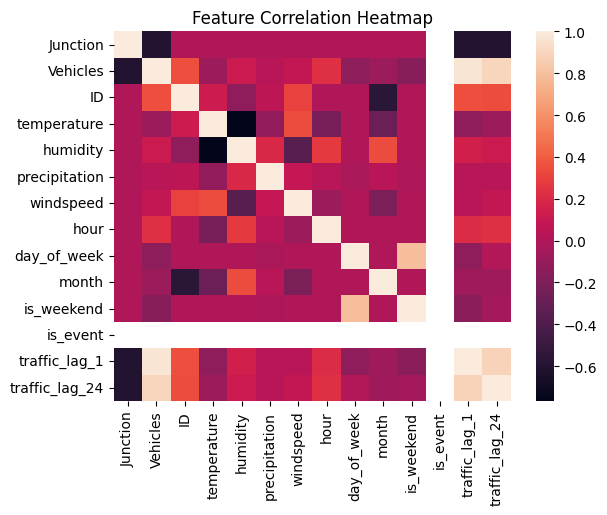

In [ ]:
corr_matrix = df.select_dtypes(include='number').corr()

target_corr = corr_matrix['Vehicles'].sort_values(ascending=False)
print(target_corr)

plt.figure()
sns.heatmap(corr_matrix, annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


Tree based feature

In [ ]:
# Select features and target
X = df.drop(columns=['Vehicles'])   # Only drop the TARGET
y = df['Vehicles']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Extract feature importance
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)
print(feature_importance)


traffic_lag_1     0.940766
traffic_lag_24    0.014390
hour              0.013996
ID                0.006527
temperature       0.005353
windspeed         0.005139
humidity          0.003796
day_of_week       0.003480
Junction          0.002145
month             0.001966
precipitation     0.001721
is_weekend        0.000720
is_event          0.000000
dtype: float64


In [ ]:
selected_features = feature_importance[feature_importance > 0.02].index.tolist()
X_selected = df[selected_features]


In [ ]:
X_selected.head()

,traffic_lag_1
Datetime,
2015-11-02 00:00:00,15.0
2015-11-02 01:00:00,14.0
2015-11-02 02:00:00,12.0
2015-11-02 03:00:00,14.0
2015-11-02 04:00:00,12.0


In [ ]:
df.to_csv('feature engineering.csv')

In [ ]:
df.describe()

,Junction,Vehicles,ID,temperature,humidity,precipitation,windspeed,hour,day_of_week,month,is_weekend,is_event,traffic_lag_1,traffic_lag_24
count,43752.000000,43752.000000,4.375200e+04,43752.000000,43752.000000,43752.000000,43752.000000,43752.000000,43752.000000,43752.000000,43752.000000,8184.0,43752.000000,43752.000000
mean,2.000549,24.339253,2.016261e+10,26.916751,80.128840,0.248238,8.164680,11.500000,2.995063,6.117389,0.284147,1.0,24.338705,24.334088
std,0.816394,21.116188,5.774765e+06,2.667045,14.044451,0.877586,4.276614,6.922266,1.999331,3.618947,0.451012,0.0,21.116119,21.116349
min,1.000000,1.000000,2.015110e+10,19.300000,15.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.0,1.000000,1.000000
25%,1.000000,10.000000,2.016040e+10,24.900000,72.000000,0.000000,4.800000,5.750000,1.000000,3.000000,0.000000,1.0,10.000000,10.000000
50%,2.000000,17.000000,2.016083e+10,26.600000,84.000000,0.000000,7.400000,11.500000,3.000000,6.000000,0.000000,1.0,17.000000,17.000000
75%,3.000000,32.000000,2.017013e+10,28.700000,92.000000,0.125000,10.900000,17.250000,5.000000,10.000000,1.000000,1.0,32.000000,32.000000
max,3.000000,180.000000,2.017063e+10,36.100000,100.000000,30.700000,27.300000,23.000000,6.000000,12.000000,1.000000,1.0,180.000000,180.000000


In [ ]:
df.dtypes

,0
Junction,int64
Vehicles,int64
ID,int64
temperature,float64
humidity,int64
precipitation,float64
windspeed,float64
hour,int32
day_of_week,int32
month,int32
